# DES cluster 6x2pt + N: how parameters change the joint data vector

This notebook evaluates the full joint data vector of the DES Y6-like analysis of [arXiv:2503.13631](https://arxiv.org/abs/2503.13631) with this project's compiled Cosmolike interface. Its options mirror [EXAMPLE_EVALUATE2.yaml](EXAMPLE_EVALUATE2.yaml), which runs the likelihood `des_cluster.combo_6x2pt_N` (CL+3x2pt in the paper): the cluster blocks of 4x2pt + N together with the galaxy 3x2pt blocks, that is cosmic shear, galaxy–galaxy lensing and the galaxy clustering of all six MagLim lens bins. After a reference model at the fiducial point, the notebook varies one parameter at a time, five values each, and shows every block as a ratio to the reference: $\Omega_m$, $A_s$, the mass–richness relation ($\ln\lambda_0$, $\sigma_{\rm int}$), the selection bias ($b_{s2}$, $r_0$), the angular binning and Cosmolike's accuracy setting. It ends with the $\chi^2$. [EXAMPLE_EVALUATE1.ipynb](EXAMPLE_EVALUATE1.ipynb) walks through the cluster observables and their halo-model ingredients at the fiducial point.

### Galaxy clusters, richness and bins

A galaxy cluster is a massive dark-matter halo, roughly $10^{14}$ to $10^{15}\,M_\odot/h$, that hosts many galaxies. Its mass is not observed directly. The cluster finder measures instead the **richness** $\lambda$, a probability-weighted count of the cluster's red-sequence member galaxies, and the analysis uses richness as a noisy **mass proxy**: the mass–richness relation gives the probability distribution of $\lambda$ for a halo of mass $M$ at redshift $z$. Clusters are grouped into

- 3 redshift bins in the cluster's photometric redshift $z_\lambda$, with edges 0.2, 0.4, 0.55 and 0.65, and
- 4 richness bins, with edges 20, 30, 45, 60 and 500,

so each cluster observable is computed for $3\times4=12$ cluster samples.

### The observables

| block | observable | what it measures |
|---|---|---|
| `ss` | cosmic shear, $\xi_\pm(\theta)$ | the correlation functions of the shapes of source galaxies, distorted by lensing along the line of sight, for each of the 10 source-bin pairs |
| `gs` | galaxy–galaxy lensing, $\gamma_t(\theta)$ | the tangential shear of source galaxies around MagLim lens galaxies, for 6 lens × 4 source bins |
| `gg` | galaxy clustering, $w(\theta)$ | the angular correlation function of the MagLim lens galaxies (the DES lens sample selected with a redshift-dependent magnitude limit), in each of the 6 lens bins |
| `cg` | cluster–galaxy clustering, $w_{cg}(\theta)$ | the angular cross-correlation of the clusters with MagLim lens galaxies, one lens bin per cluster redshift bin |
| `N` | cluster counts | the expected number of clusters of each (redshift, richness) bin in the 4143 deg² survey area: absolute numbers, not density contrasts |
| `cc` | cluster clustering, $w_{cc}(\theta)$ | the angular correlation function of the clusters, for every pair of richness bins in one redshift bin |
| `cs` | cluster lensing, $\Sigma=Y\gamma_t$ | the tangential shear $\gamma_t(\theta)$ of source galaxies around the clusters, localized by the $Y$ transform below |

### The $Y$ transform and its zero last bin

The tangential shear at projected radius $R$ responds to all the mass enclosed within $R$, including the cluster core, which is hard to model. The data vector therefore stores the localized statistic $\Sigma=Y\gamma_t$ (eq. 15 of the paper; [Park, Rozo & Krause 2021](https://arxiv.org/abs/2004.07504)). $Y$ is a fixed $20\times20$ matrix acting on the angular bins of $\gamma_t$. It turns the shear profile into the difference $\Sigma_m(R)-\Sigma_m(R_{\max})$ of the projected mass density $\Sigma_m$ between $R$ and the outermost radius $R_{\max}$, divided by the critical surface density of the cluster–source geometry, so $\Sigma$ is dimensionless like $\gamma_t$. This difference depends only on the mass profile between $R$ and $R_{\max}$. At $R=R_{\max}$ it subtracts a value from itself: the last angular bin of every cluster-lensing row is exactly zero, and the mask always removes it.

### The joint data vector and the synthetic data

Both cluster likelihoods read one joint vector of 2812 entries, with the blocks in the order of the table above: cosmic shear (400 entries), galaxy–galaxy lensing (480), galaxy clustering (120), cluster–galaxy clustering (240), counts (12), cluster clustering (600) and cluster lensing (960). The two likelihoods differ only in the scale-cut mask: the 6x2pt + N mask used here keeps 1429 entries; the 4x2pt + N mask keeps 889 and removes `ss` and `gs` entirely.

No public DES cluster data vector exists, so the data are synthetic: the data vector is this model at the fiducial point of Table I of the paper, without noise, and the covariance is an analytic Gaussian covariance. The data points in the figures therefore lie on the model curves by construction, and their error bars are the square roots of the covariance diagonal. Nothing here is a DES measurement.

### How the notebook drives Cosmolike

The project's notebook wrappers (`interface/cosmolike_des_cluster_notebook_wrappers.py`, imported as `nw`) repeat the likelihood's steps on every call: run CAMB, hand the power spectra, the growth factor and the distances to the interface (`set_cosmology`), set the nuisance parameters, and read an observable. The [project README](README.md#des_cluster_wrappers) lists the wrappers and the plotting functions.

The sections follow the order of a likelihood evaluation: the setup and the CAMB import; the likelihood options; the fiducial point; the initialization of Cosmolike and the layout of the joint data vector. Then come the plotting conventions, the reference model, the parameter sweeps, the angular binning, Cosmolike's accuracy setting, and the $\chi^2$.

## Units, bins and plotting conventions

- **Angles.** The real-space statistics use 20 logarithmic angular bins between 2.5 and 250 arcmin; the wrappers return the bin centers $\theta$ in arcmin.
- **Bin indices.** Arrays and the `richness` and `pairs` arguments count bins from 0; panel labels and legends count from 1.
- **Array layouts.** Each wrapper returns the angle (or multipole) axis first, then the bins:

| observable | wrapper | array axes |
|---|---|---|
| counts | `nw.N_cluster` | [richness, cluster z] |
| cluster lensing $\Sigma$ | `nw.sigma_cluster` | [$\theta$, richness, cluster z, source] |
| $w_{cc}$ | `nw.w_cc` | [$\theta$, richness 1, richness 2, cluster z] |
| $w_{cg}$ | `nw.w_cg` | [$\theta$, richness, cluster z, lens]; zero outside the dataset's pairs |
| $\xi_+$, $\xi_-$ | `nw.xi` | two arrays [$\theta$, source, source] |
| galaxy–galaxy lensing $\gamma_t$ | `nw.gamma_t` | [$\theta$, lens, source] |
| galaxy clustering $w$ | `nw.w_theta` | [$\theta$, lens, lens], autocorrelations on the diagonal |

- **Units.** Counts are numbers of clusters in the survey area. Shears, $\Sigma$, the correlation functions $w$ and the spectra $C_\ell$ are dimensionless. Halo masses are $M_{200m}$ in $M_\odot/h$: the mass inside the radius within which the mean density is 200 times the mean matter density of the Universe. Wavenumbers $k$ are in $h/{\rm Mpc}$, number densities in $(h/{\rm Mpc})^3$ and power spectra in $({\rm Mpc}/h)^3$. Inside the C library lengths are measured in units of $c/H_0$; the wrappers convert.
- **Plots without a reference** draw the absolute value of the quantity on a logarithmic axis, one panel per redshift bin or bin pair, with the richness bins drawn as line styles inside each panel (the counts put the richness on the x axis instead). `rescale = 1` multiplies each panel by its own power of ten, $\alpha$, so that all panels share one y axis.
- **Plots with a reference** (a `*_ref` argument) draw the fractional difference, value/reference $-\,1$; `ylim` then gives the band of value/reference, drawn as `ylim` $-\,1$.
- **Data points** are the synthetic data with $\pm1\sigma$ error bars, drawn only where the scale cuts keep them. A point survives when $\theta>R/\chi(\bar z)$, with $\chi(\bar z)$ the comoving distance to the mean redshift of the bin at the fiducial cosmology and $R=2$ (cluster lensing), 8 ($w_{cg}$, $w_{gg}$) or 16 ($w_{cc}$) comoving Mpc/$h$. The mask also removes a (cluster bin, source bin) pair of cluster lensing entirely when the upper edge of the cluster bin lies above the mean redshift of the source bin, so that panel has no data points.

## Setup: threads, imports and figure style

The next cell sets the number of OpenMP threads for Cosmolike's C loops. `OMP_NUM_THREADS` keeps a value exported in the shell before Jupyter started and defaults to 4 otherwise; the wrappers hand it to `ci.set_omp_threads` before each calculation. The cell imports the compiled interface `cosmolike_des_cluster_interface` as `ci` and fixes the figure style. `text.usetex = True` typesets every figure label with LaTeX, which needs a LaTeX installation (the comment in the cell lists the packages). The inline figure resolution is moderate because the notebook is stored with its outputs.

In [1]:
%matplotlib inline
import sys, platform, os
# threads of cosmolike's OpenMP regions; a value already set in the shell wins
os.environ.setdefault('OMP_NUM_THREADS', '4')
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import cosmolike_des_cluster_interface as ci
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 15
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# Resolution of the inline figures. The notebook is committed with its
# outputs, so a moderate value keeps the file at a few MB; for sharper
# figures on screen raise it, or add the line
# %config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.dpi'] = 72
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# text.usetex = True typesets all figure text with LaTeX. It needs the system packages
# texlive-latex-base, texlive-latex-extra, texlive-fonts-recommended, dvipng, ghostscript
# and cm-super; set it to False when they are missing.
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster


## CAMB and the shared notebook packages

Cosmolike does not solve the Boltzmann equations itself. The linear and nonlinear matter power spectra, the growth factor and the comoving distances come from CAMB through `cnu.get_camb_cosmology` of the shared package `cosmolike_notebook_utils`. The notebook never calls CAMB directly: a wrapper calls it when a cosmology is first requested and keeps the last result, so repeated calls at one cosmology cost one CAMB run. The CAMB import below only reports which CAMB build Python loads; `get_camb_cosmology` imports CAMB at its first call and receives this same module, because Python keeps a single copy of each imported module.

The cell also imports the shared package as `cnu`, its cluster plotting module `plot_datavectors_cluster` as `pdc` (it is not part of the `cnu` namespace), and the project wrappers as `nw`.

In [2]:
# IMPORT CAMB
# The directory below names a Linux x86-64 CAMB build. When it does not exist (for
# example on macOS), Python skips that sys.path entry and imports the CAMB installed in
# Cocoa's Python environment; the printed path shows which CAMB was loaded.
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))
# the cluster data-vector plots live in their own module of that package
# (it is not part of the cnu.* namespace): call them as pdc.plot_N_cluster,
# pdc.plot_sigma_cluster_tomo, pdc.plot_wcc_tomo, pdc.plot_wcg_tomo, ...
from cosmolike_notebook_utils import plot_datavectors_cluster as pdc

# IMPORT THE PROJECT'S NOTEBOOK WRAPPERS (projects/des_cluster/interface):
# the cluster observables, the halo-model ingredients, and the chi2
# wrappers every notebook of this project shares
import cosmolike_des_cluster_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb


Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster/interface/cosmolike_des_cluster_notebook_wrappers.py


## The likelihood options

The values below repeat the likelihood block of `EXAMPLE_EVALUATE2.yaml`. `nw.configure` stores them in the wrappers before the initialization reads them, and it rejects an unknown option name. The cluster switches choose the model:

| option | value | meaning |
|---|---|---|
| `cluster_kernel_mode` | 0 | radial weight of each cluster bin in the two-point functions: the comoving volume times the selection kernel $\langle\phi_i\vert z\rangle$, as in the DES analysis; 1 would also weight by the cluster abundance |
| `cluster_selection_model` | 2 | the scale-dependent selection bias $B(\theta)$ of eq. 23, applied to the data vector: richness-selected clusters sit preferentially in filaments along the line of sight, which boosts their lensing and clustering signals |
| `cluster_ytransform` | 1 | cluster lensing stored as $\Sigma=Y\gamma_t$; 0 would store $\gamma_t$ |
| `cluster_include_ia` | 1 | intrinsic alignment of the source galaxies in the two-halo cluster-lensing term |
| `cluster_magnification` | $-2$ | coefficient $C_c$ of the lensing magnification of the cluster sample (eq. 28); 0 switches it off |
| `cluster_hmf_alpha_mode` | 0 | amplitude of the Tinker et al. (2010) mass function fixed at 0.368 at every redshift, as in the DES analysis |

The other options: `integration_accuracy = 1` selects the quadrature level these redshift distributions need (the MagLim tails reach $z\approx3$); `lmax` is the largest multipole of the internal $C_\ell$ tables summed into the real-space statistics; `non_linear_emul = 2` takes the nonlinear matter power spectrum from CAMB's halofit, a fitting formula calibrated on N-body simulations; `IA_model = 0` selects the nonlinear-alignment (NLA) model of intrinsic alignments, whose amplitude is zero at the fiducial point.

In [3]:
# The options of EXAMPLE_EVALUATE2.yaml: CL+3x2pt (6x2pt + N) on the
# synthetic DES Y6-like data = cosmic shear, galaxy-galaxy lensing and
# galaxy clustering (MagLim), plus the cluster blocks of 4x2pt + N: cluster
# counts, cluster lensing, w_cc and w_cg (EXAMPLE_EVALUATE1.ipynb walks
# through those at the fiducial point, with the halo-model ingredients)
CLprobe = "6x2pt_N"

path = "../../external_modules/data/des_cluster"
data_file = "des_cluster_y6_6x2ptN.dataset"

non_linear_emul = 2
IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)
lmax = 75000
integration_accuracy = 1

cluster_kernel_mode = 0       # 0 = volume only (what DES ran), 1 = abundance weighted
cluster_selection_model = 2   # 0 = none, 1 = Y1 (mass dependent), 2 = Y6 (scale dependent, eq 23)
cluster_ytransform = 1        # 1 = Sigma = Y gamma_t (eq 15), 0 = gamma_t
cluster_include_ia = 1
cluster_magnification = -2.0  # C_c (eq 28)
cluster_hmf_alpha_mode = 0    # 0 = Tinker alpha = 0.368 at every z (what DES ran)

# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(path=path,
             data_file=data_file,
             lmax=lmax,
             integration_accuracy=integration_accuracy,
             non_linear_emul=non_linear_emul,
             IA_model=IA_model,
             IA_redshift_evolution=IA_redshift_evolution,
             IA_code=IA_code,
             cluster_kernel_mode=cluster_kernel_mode,
             cluster_selection_model=cluster_selection_model,
             cluster_ytransform=cluster_ytransform,
             cluster_include_ia=cluster_include_ia,
             cluster_magnification=cluster_magnification,
             cluster_hmf_alpha_mode=cluster_hmf_alpha_mode)

## The fiducial point and the nuisance parameters

The wrappers module holds the fiducial point as plain constants: Table I of the paper, the point of the synthetic data vector. Every wrapper falls back to these values, so a call names only what it changes, for example `nw.N_cluster(omegam=0.31)`. The cosmology has $w=-1$ and one massive neutrino with $\Omega_\nu h^2=0.00083$ ($m_\nu\approx0.077$ eV).

The cluster nuisance parameters form two vectors.

- `MOR` = [$\ln\lambda_0$, $A_\lambda$, $\sigma_{\rm int}$, $B_\lambda$], the lognormal mass–richness relation of eqs. 18–19. The mean log-richness of a halo of mass $M$ at redshift $z$ is
$$\langle\ln\lambda\,|\,M,z\rangle=\ln\lambda_0+A_\lambda\ln\frac{M}{M_{\rm piv}}+B_\lambda\ln\frac{1+z}{1+z_{\rm piv}},\qquad M_{\rm piv}=5\times10^{14}\,M_\odot/h,\quad 1+z_{\rm piv}=1.45,$$
and $\ln\lambda$ scatters around it with the variance $\sigma^2_{\rm int}+(\bar\lambda-1)/\bar\lambda^2$, where $\bar\lambda=e^{\langle\ln\lambda\rangle}$: an intrinsic scatter plus a Poisson term.
- `SEL` = [$b_{s1}$, $b_{s2}$, $r_0$, $s_3$], the selection bias of eq. 23, $B(\theta)=b_{s1}+b_{s2}\exp[-\theta\chi(\bar z)/r_0]$, with $r_0$ in comoving Mpc/$h$ and $\chi(\bar z)$ the comoving distance to the mean redshift of the cluster bin. $s_3$, the power of an extra factor $(1+\bar z)/1.45$, is zero in the paper's model.

The galaxy and source nuisance parameters (shifts of the photometric-redshift distributions, linear galaxy biases, shear calibration, intrinsic alignment) also take their Table I values.

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_des_cluster_notebook_wrappers.py): Table I of
# arXiv 2503.13631, the point of the synthetic data vector
# (scripts/make_synthetic_data.py). The names are imported so the sweep
# cells below can build shifted vectors from them; override any value per
# call instead, e.g. nw.N_cluster(omegam=0.31) or nw.N_cluster(MOR=[...]).
from cosmolike_des_cluster_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    DES_CL_LNLAMBDA0, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA,
    DES_CL_BS1, DES_CL_BS2, DES_CL_R0, DES_CL_BSZ)
print("cosmology: As_1e9 = %g, ns = %g, H0 = %g, omegab = %g, omegam = %g, mnu = %.5f eV, w = %g"
      %(As_1e9, ns, H0, omegab, omegam, mnu, w))
print("mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda):", nw.MOR_FID)
print("selection bias (b_s1, b_s2, r_0 [Mpc/h], s3):", nw.SELECTION_FID)

cosmology: As_1e9 = 2.19, ns = 0.96859, H0 = 69, omegab = 0.048, omegam = 0.3, mnu = 0.07719 eV, w = -1
mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda): [4.26, 0.943, 0.15, 0.207]
selection bias (b_s1, b_s2, r_0 [Mpc/h], s3): [1.1, 0.2, 30.0, 0.0]


## Initialize Cosmolike and read the joint data-vector layout

`nw.init_cosmolike` runs the likelihood's initialization once, in the likelihood's order: the probes of `CLprobe`, the angular binning, the lens and source redshift distributions, the survey area, the cluster model switches, the richness bins, the selection kernels $\langle\phi_i|z\rangle$ (the probability that a cluster at true redshift $z$ is assigned to observed redshift bin $i$) and the (cluster redshift bin, lens bin) pairs of $w_{cg}$. With `with_data = True` it also loads the mask, the synthetic data vector and its covariance, which the data overlays and the $\chi^2$ need. `CLprobe` decides only which blocks enter the masked data vector; every observable wrapper works with any probe choice.

The cell then reads the bins back from the dataset file. `ci.compute_data_vector_cluster_sizes` and `ci.compute_data_vector_cluster_starts` give the length and the first index of each block in the 2812-entry vector, and `ci.get_mask_cluster` the mask (1 keeps an entry); the cell prints how many entries of each block the 6x2pt + N mask keeps. Inside each block the angular bins of one tomographic row are consecutive.

In [5]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike: the init
# chain of the likelihood, likelihood/_cosmolike_prototype_base.py).
# with_data = True also loads the mask, the synthetic data vector and its
# covariance (the data overlays and the chi2 below need them)
ini = nw.init_cosmolike(CLprobe=CLprobe, with_data=True)

# bins of the dataset
dataset = nw.dataset_info()
richness_edges = dataset["richness_edges"]
zbin_edges = dataset["cluster_zbin_edges"]
nrichness = len(richness_edges) - 1
ncluster = len(zbin_edges) - 1
nsource = dataset["source_ntomo"]
nlens = dataset["lens_ntomo"]
# One legend label per richness bin: the list comprehension formats one label per bin.
richness_label = [r"$\lambda \in [%g, %g)$"%(richness_edges[i], richness_edges[i+1]) for i in range(nrichness)]
print("richness bins:", richness_edges, " cluster z bins:", zbin_edges)
print("source bins:", nsource, " lens bins:", nlens, " survey area [deg2]:", dataset["survey_area_deg2"])
# (cluster z bin, lens bin) pairs of w_cg
print("w_cg pairs (cluster z bin, lens bin):", np.array(ci.get_cg_redshift_bins()).astype(int).tolist())

# blocks of the joint data vector and what the scale cuts keep
dv_names = ["ss", "gs", "gg", "cg", "N", "cc", "cs"]
dv_sizes = np.array(ci.compute_data_vector_cluster_sizes())
dv_starts = np.array(ci.compute_data_vector_cluster_starts())
dv_mask = np.array(ci.get_mask_cluster()).astype(bool)
# enumerate gives each block's index i together with its name.
for i, name in enumerate(dv_names):
    print("%2s: %4d entries, %4d after the scale cuts"%(name, dv_sizes[i], dv_mask[dv_starts[i]:dv_starts[i] + dv_sizes[i]].sum()))

richness bins: [ 20.  30.  45.  60. 500.]  cluster z bins: [0.2  0.4  0.55 0.65]
source bins: 4  lens bins: 6  survey area [deg2]: 4143.0
w_cg pairs (cluster z bin, lens bin): [[0, 0], [1, 1], [2, 2]]
ss:  400 entries,  190 after the scale cuts
gs:  480 entries,  312 after the scale cuts
gg:  120 entries,   69 after the scale cuts
cg:  240 entries,  128 after the scale cuts
 N:   12 entries,   12 after the scale cuts
cc:  600 entries,  230 after the scale cuts
cs:  960 entries,  488 after the scale cuts


## How the plots show the cluster blocks

The cluster blocks are drawn by `plot_datavectors_cluster` (imported as `pdc`), the 3x2pt blocks by the galaxy functions of `cosmolike_notebook_utils` (`cnu`). Both follow the same conventions: the first argument is a list of models, colored by `param` with a colorbar; without a reference the panels show the quantity itself, and with a reference (`*_ref`) they show the fractional difference, value/reference $-\,1$, in the band `ylim` $-\,1$.

The cluster plots add one index, the richness bin, drawn as curves inside each panel: the color follows the parameter value and the line style the richness bin. Each panel is labeled with its bin or bin pair, counted from 1.

The cluster plotting functions of `plot_datavectors_cluster` (`pdc`) form one family per block:

| function | one panel per | curves inside a panel |
|---|---|---|
| `pdc.plot_N_cluster` | cluster redshift bin, with the richness on the x axis | one staircase per model |
| `pdc.plot_gammat_cluster_tomo`, `pdc.plot_sigma_cluster_tomo`, `pdc.plot_C_cs_tomo_limber` | (cluster z bin, source bin) pair: columns are cluster z bins, rows source bins | the richness bins |
| `pdc.plot_wcc_tomo`, `pdc.plot_C_cc_tomo_limber` | cluster redshift bin | the richness pairs (by default the auto pairs) |
| `pdc.plot_wcg_tomo`, `pdc.plot_C_cg_tomo_limber` | (cluster z bin, lens bin) pair of the dataset | the richness bins |

`richness` selects the richness bins to draw, and `pairs` the richness pairs of $w_{cc}$ (the panels of $w_{cg}$), counted from 0. `data` overlays the synthetic data and skips the NaN entries that the mask removes.

## What one wrapper call does: CAMB, `set_cosmology` and the nuisance setters

Every observable wrapper (`nw.N_cluster`, `nw.sigma_cluster`, `nw.w_cc`, ...) sets the complete state of the interface before it reads its observable, so no call depends on which wrapper ran before it. One call runs these steps:

1. **CAMB.** `cnu.get_camb_cosmology` runs CAMB for the requested cosmology, unless the previous call used the same one. It returns the natural logarithm of the linear and nonlinear matter power spectra in $({\rm Mpc}/h)^3$ on a grid of $\log_{10}k$ ($k$ in $h/{\rm Mpc}$) and redshift; the growth factor $G(z)=D(z)\,(1+z)$ on a dense redshift grid, divided by its value at the last redshift of the power-spectrum grid; the comoving distance $\chi(z)$ in Mpc/$h$; $\Omega_\nu h^2$; and the linear power spectrum of cold dark matter plus baryons, which the halo model of the clusters uses.
2. **Accuracy and binning.** `ci.init_accuracy_boost` and `ci.init_binning` reset the numerical accuracy and the angular bins.
3. **`ci.set_cosmology`** hands $\Omega_m$, $\Omega_b$, $H_0$ and these tables to the C library.
4. **Nuisance setters**, in the likelihood's order: the lens galaxies (`set_point_mass`, `set_nuisance_bias`, `set_nuisance_clustering_photoz`), the sources (`set_nuisance_shear_calib`, `set_nuisance_shear_photoz`, `set_nuisance_ia`) and the clusters (`set_nuisance_cluster_mor` with `MOR`, `set_nuisance_cluster_selection` with `SEL`). A vector that the call does not name takes its fiducial value.
5. **The observable**, for example `ci.N_cluster_tomo()` for the counts or `ci.w_sigma_cluster_tomo()` for cluster lensing.

The reference model below comes from the notebook's first wrapper calls; the first of them includes the CAMB run.

## The reference model at the fiducial point

The next cell computes every block at the fiducial point; these arrays are the references of all the ratios below. The cluster blocks come from `nw.N_cluster`, from `nw.sigma_cluster` ($\Sigma=Y\gamma_t$ times the selection bias and the shear calibration, as in the data vector), and from `nw.w_cc` and `nw.w_cg` with `selection_bias = True`, so that they carry $B(\theta)^2$ and $B(\theta)$ as the data vector does. The 3x2pt blocks come from `nw.xi` (cosmic shear $\xi_\pm$), `nw.gamma_t` (galaxy–galaxy lensing) and `nw.w_theta` (galaxy clustering), in the layouts of the galaxy plotting functions. All seven calls share one cosmology and therefore one CAMB run. The two figures that follow overlay the synthetic data on the counts and on $\Sigma$.

In [6]:
# Every block at the fiducial point: the reference of the ratios below.
# The wrappers keep the last CAMB run, so these calls cost one CAMB run.
# selection_bias = True: w_cc and w_cg as the data vector carries them
N_ref = nw.N_cluster()                         # [richness, cluster z]
sigma_ref = nw.sigma_cluster()                 # (theta, [theta, richness, cluster z, source])
wcc_ref = nw.w_cc(selection_bias=True)         # (theta, [theta, richness 1, richness 2, cluster z])
wcg_ref = nw.w_cg(selection_bias=True)         # (theta, [theta, richness, cluster z, lens])
xi_ref = nw.xi()                               # (theta, xi+, xi-): [theta, source, source]
gammat_ref = nw.gamma_t()                      # (theta, [theta, lens, source])
wtheta_ref = nw.w_theta()                      # (theta, [theta, lens, lens])
theta = sigma_ref[0]

# the cluster blocks of the synthetic data and of their 1-sigma errors, in
# the layouts of the model arrays (NaN where the scale cuts remove them)
data, error = nw.data_cluster_blocks()

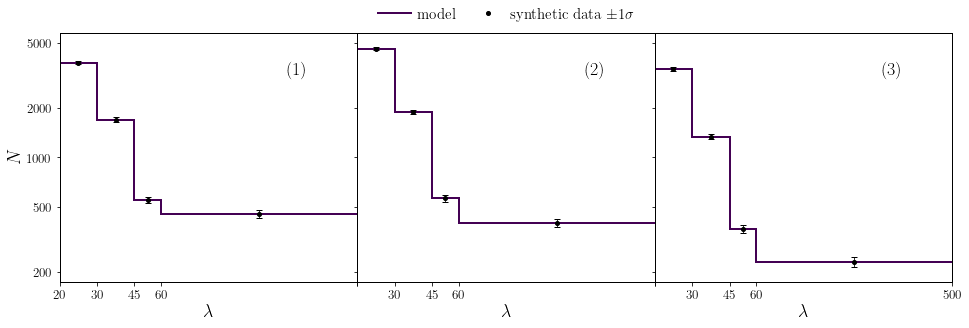

In [7]:
# counts: one panel per cluster z bin, the richness on the x axis
pdc.plot_N_cluster(N = [N_ref],
                   richness_edges = richness_edges,
                   data = (data["N"], error["N"]),
                   datalabel = r"synthetic data $\pm 1\sigma$",
                   legend = ["model"],
                   cmap = "viridis",
                   linewidth = [2.0],
                   figsize = (16, 4.5),
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

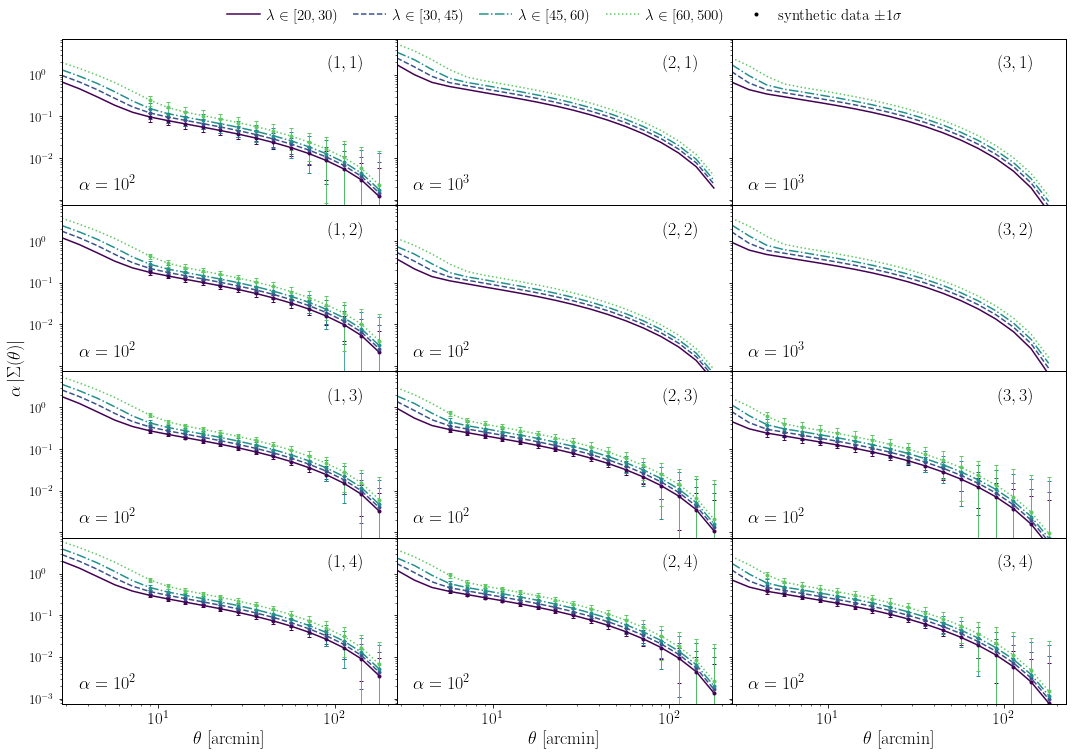

In [8]:
# cluster lensing as the data vector holds it (Sigma = Y gamma_t): columns
# = cluster z bins, rows = source bins, curves = richness bins; the points
# are the synthetic data where the scale cuts keep them
pdc.plot_sigma_cluster_tomo(theta_sigma = [sigma_ref],
                            data = (theta, data["cs"], error["cs"]),
                            datalabel = r"synthetic data $\pm 1\sigma$",
                            richnesslabel = richness_label,
                            cmap = "viridis",
                            linewidth = [1.5],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

## Sweep of the matter density $\Omega_m$

Five values of $\Omega_m$ between 0.28 and 0.32, with every other parameter at the fiducial point. Each value needs its own CAMB run, so the loop computes all seven blocks at one cosmology before moving to the next value. At fixed $A_s$, a larger $\Omega_m$ raises the amplitude of the matter fluctuations on cluster scales and the abundance of massive halos, and it strengthens lensing. The figures show value/reference $-\,1$, colored by $\Omega_m$; the first $\Sigma$ figure instead draws $\Sigma$ itself for the lowest richness bin, one curve per parameter value.

In [9]:
param = np.linspace(0.28, 0.32, 5)
# One empty list per block; each pass of the loop appends one array to each list.
N_param, sigma_param, wcc_param, wcg_param = [], [], [], []
xi_param, gammat_param, wtheta_param = [], [], []
for x in param:
    # every block at one cosmology before moving on: the wrappers keep the
    # last CAMB run, so the sweep costs one CAMB run per parameter value
    N_param.append(nw.N_cluster(omegam=x))
    sigma_param.append(nw.sigma_cluster(omegam=x))
    wcc_param.append(nw.w_cc(selection_bias=True, omegam=x))
    wcg_param.append(nw.w_cg(selection_bias=True, omegam=x))
    xi_param.append(nw.xi(omegam=x))
    gammat_param.append(nw.gamma_t(omegam=x))
    wtheta_param.append(nw.w_theta(omegam=x))

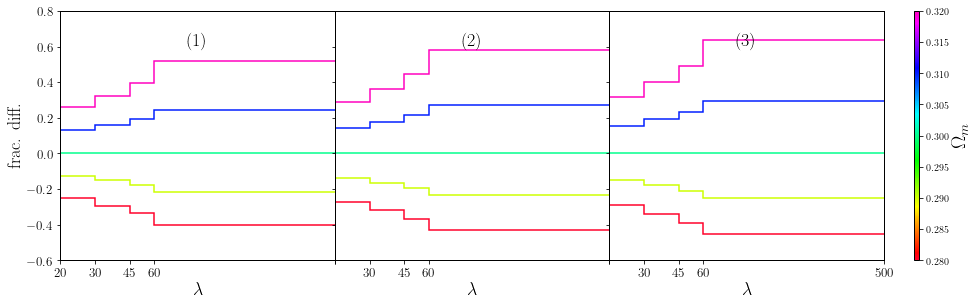

In [10]:
# Plot the ratio over the reference model
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$\Omega_m$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 1.8],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

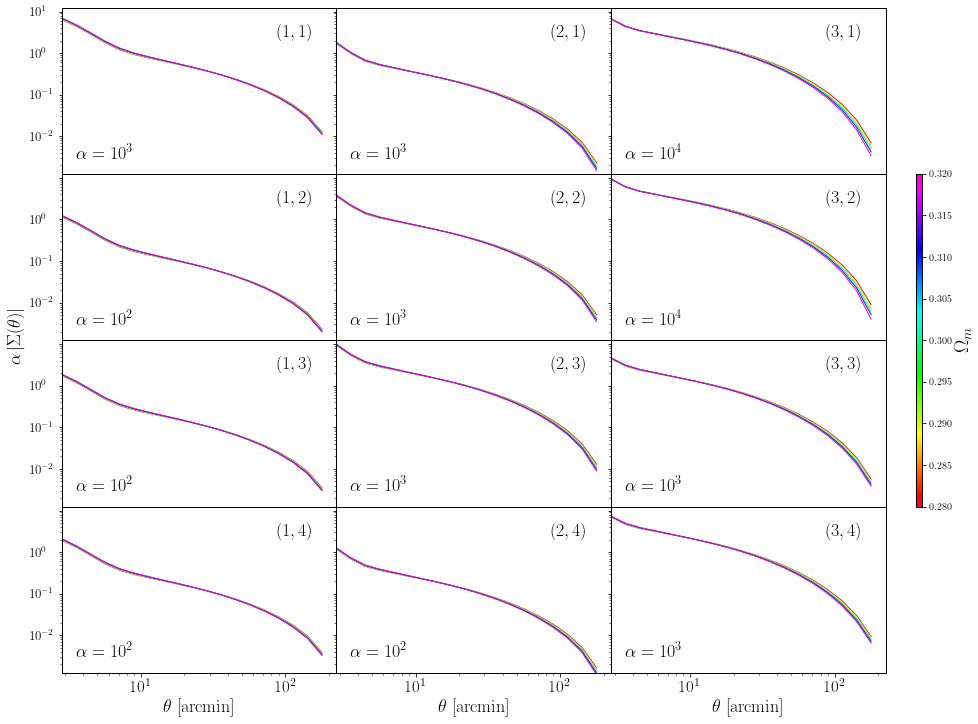

In [11]:
# Sigma itself for the lowest richness bin (richness counts from 0): one
# curve per parameter value in each panel
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            param = param,
                            colorbarlabel = r"$\Omega_m$",
                            richness = 0,
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

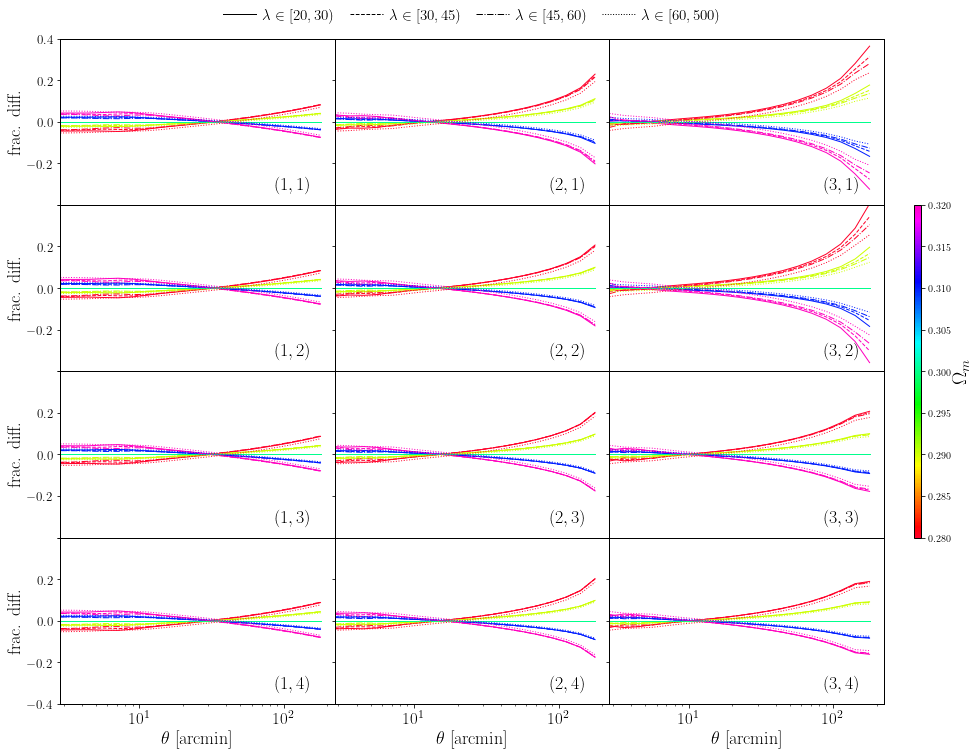

In [12]:
# ... and the ratio for every richness bin: the color is the parameter
# value, the line style the richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$\Omega_m$",
                            richnesslabel = richness_label,
                            ylim = [0.6, 1.4],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

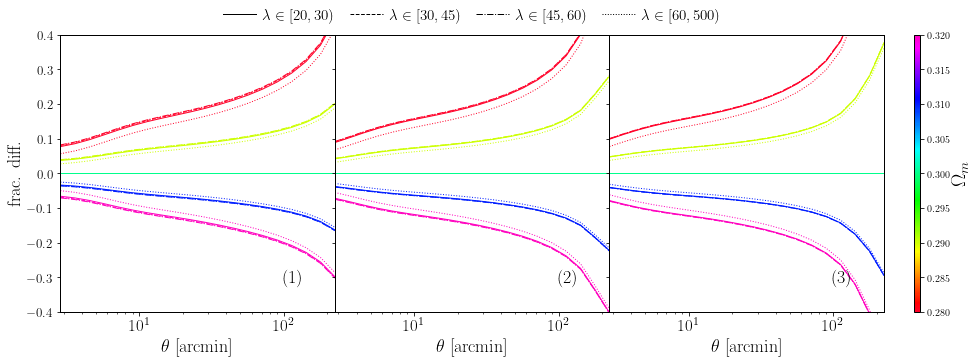

In [13]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$\Omega_m$",
                  richnesslabel = richness_label,
                  ylim = [0.6, 1.4],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

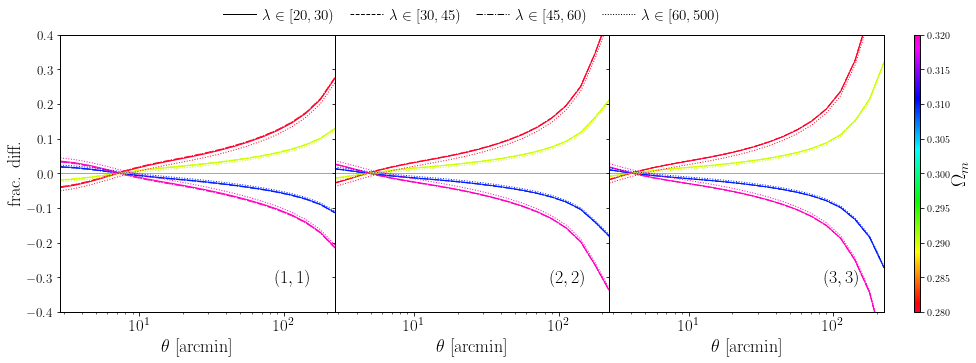

In [14]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$\Omega_m$",
                  richnesslabel = richness_label,
                  ylim = [0.6, 1.4],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

## The 3x2pt blocks in the $\Omega_m$ sweep

The same cosmologies change the galaxy blocks of 6x2pt + N, drawn with the galaxy plotting functions of `cnu`:

- cosmic shear, one panel per source-bin pair in a lower triangle: $\xi_+$ as a ratio to the reference, then $\theta\,\xi_-\times10^4$ itself;
- galaxy–galaxy lensing $\gamma_t$ around the MagLim lenses, with lens bins as columns and source bins as rows. Where a lens bin lies behind the source bin, $\gamma_t$ is small and can cross zero, so its ratio leaves the band;
- galaxy clustering $w(\theta)$, one panel per lens bin.

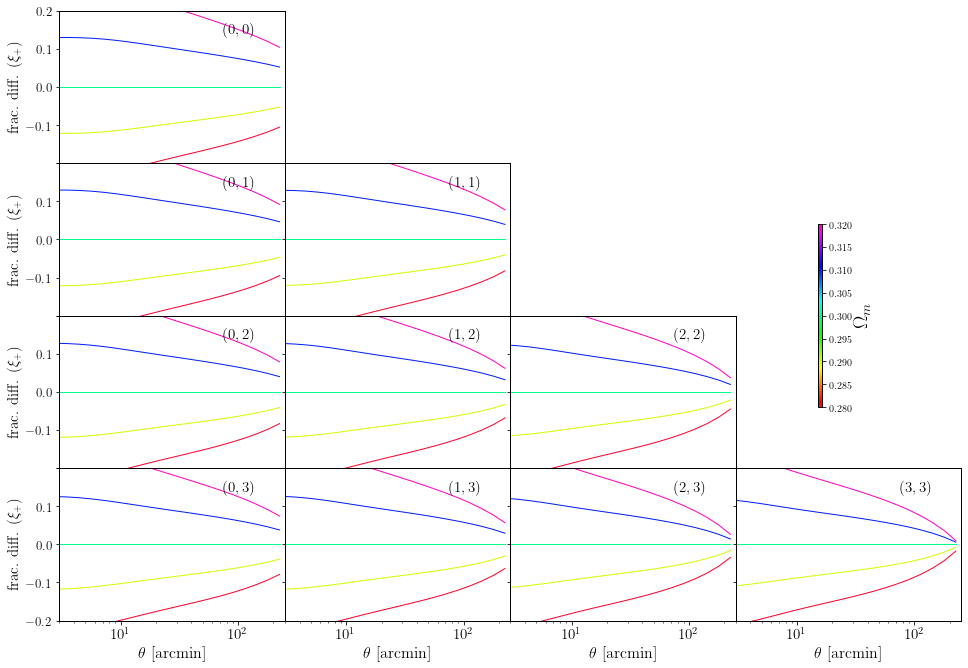

In [15]:
# cosmic shear xi_plus, as a ratio to the reference. The galaxy functions
# spread the curve colors evenly over the colormap, so with only five
# parameter values the curves sit slightly off the colorbar's colors; the
# order is the same (red = lowest value)
cnu.plot_xi(pm = 1,
            xi = xi_param,
            xi_ref = xi_ref,
            param = param,
            colorbarlabel = r"$\Omega_m$",
            ylim = [0.8, 1.2],
            yaxislabelsize = 15,
            xaxisticklabelsize = 15,
            yaxisticklabelsize = 13,
            figsize = (16, 11),
            wspace = 0.3)

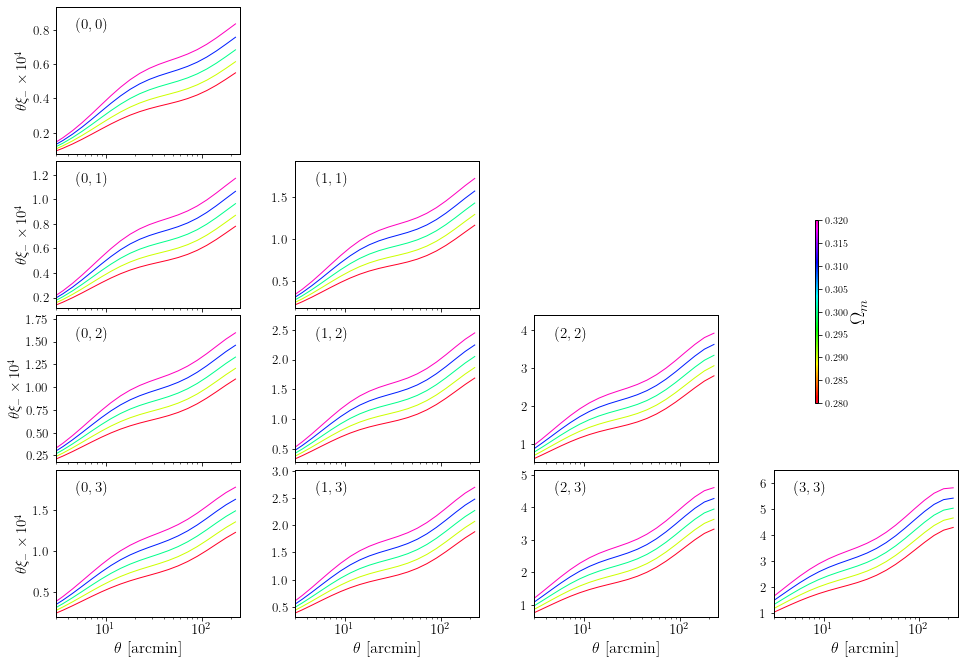

In [16]:
# xi_minus itself (theta xi_minus 10^4), one curve per parameter value
cnu.plot_xi(pm = -1,
            xi = xi_param,
            param = param,
            colorbarlabel = r"$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize = 15,
            yaxisticklabelsize = 13,
            figsize = (16, 11),
            wspace = 0.3,
            rescale = None)

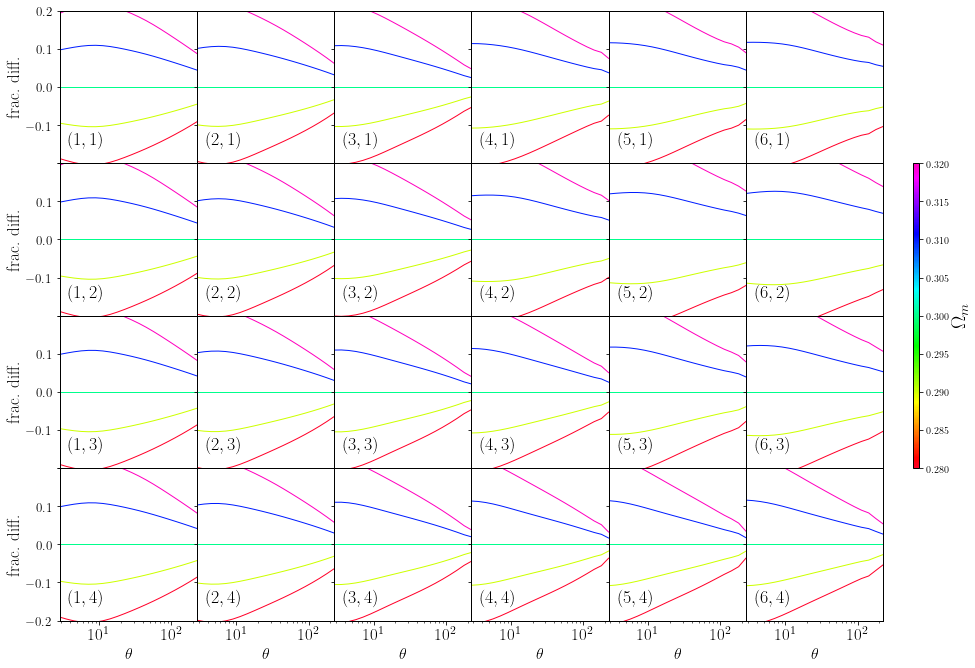

In [17]:
# galaxy-galaxy lensing: columns = lens bins, rows = source bins. The
# ratio leaves its band where gamma_t itself crosses zero (lens bins
# behind the source bin)
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_param,
                            gammat_ref = gammat_ref,
                            param = param,
                            colorbarlabel = r"$\Omega_m$",
                            bintextpos = [0.2, 0.15],
                            ylim = [0.8, 1.2],
                            figsize = (18, 11),
                            bintextsize = 18,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

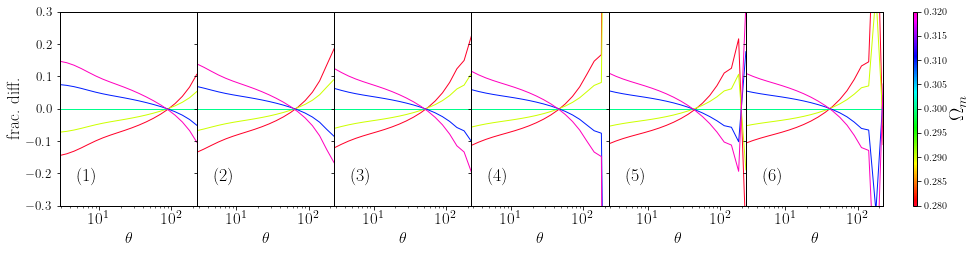

In [18]:
# galaxy clustering: one panel per lens bin
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_param,
                     theta_wtheta_ref = wtheta_ref,
                     param = param,
                     colorbarlabel = r"$\Omega_m$",
                     bintextpos = [0.2, 0.15],
                     ylim = [0.7, 1.3],
                     figsize = (18, 3.5),
                     bintextsize = 18,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 13,
                     xaxisticklabelsize = 17)

## Sweep of the primordial amplitude $A_s$

Five values of $10^9A_s$ within $\pm0.2$ of the fiducial 2.19. The linear matter power spectrum is proportional to $A_s$, so the two-point functions grow roughly in proportion to it, while the counts respond more strongly: massive halos sit in the exponential tail of the mass function. Only the cluster blocks are drawn.

In [19]:
param = np.linspace(As_1e9 - 0.2, As_1e9 + 0.2, 5)
N_param, sigma_param, wcc_param, wcg_param = [], [], [], []
for x in param:
    N_param.append(nw.N_cluster(As_1e9=x))
    sigma_param.append(nw.sigma_cluster(As_1e9=x))
    wcc_param.append(nw.w_cc(selection_bias=True, As_1e9=x))
    wcg_param.append(nw.w_cg(selection_bias=True, As_1e9=x))

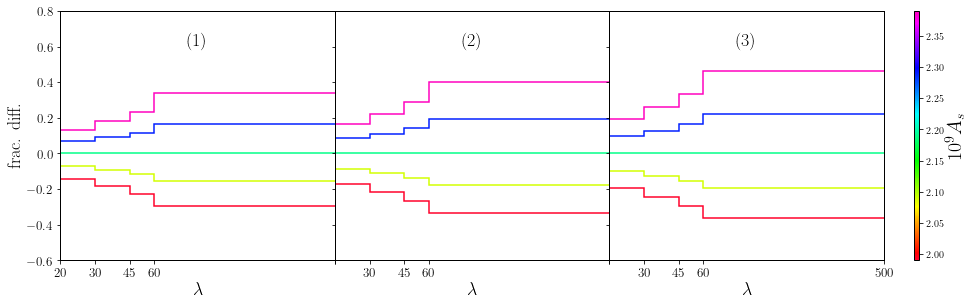

In [20]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$10^9 A_s$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 1.8],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

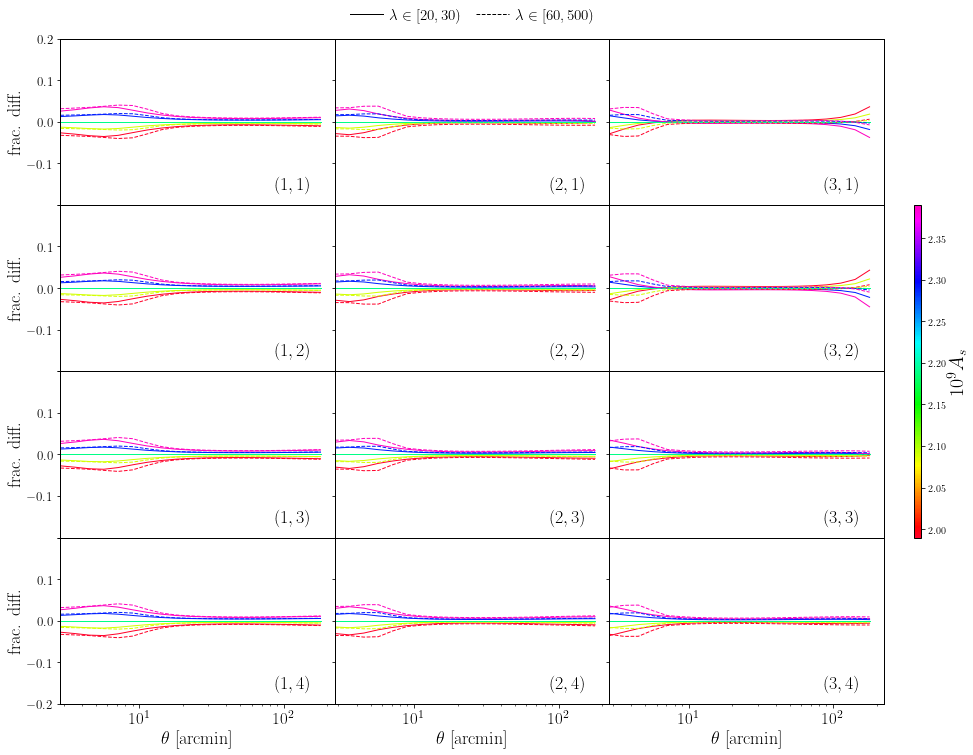

In [21]:
# the lowest and the highest richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$10^9 A_s$",
                            richnesslabel = richness_label,
                            ylim = [0.8, 1.2],
                            richness = [0, nrichness-1],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

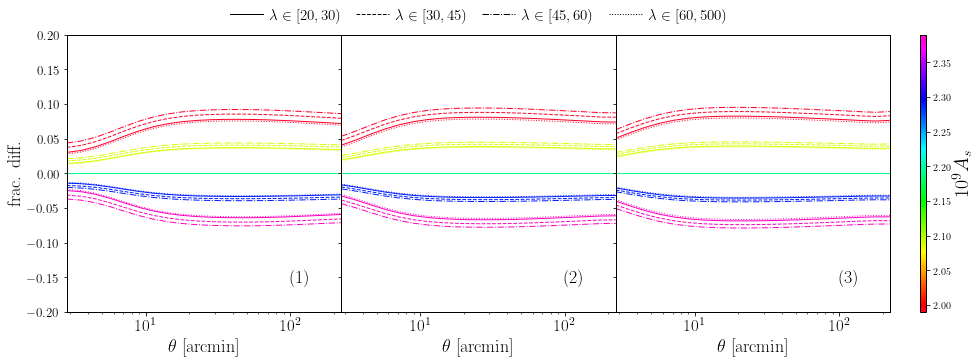

In [22]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$10^9 A_s$",
                  richnesslabel = richness_label,
                  ylim = [0.8, 1.2],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

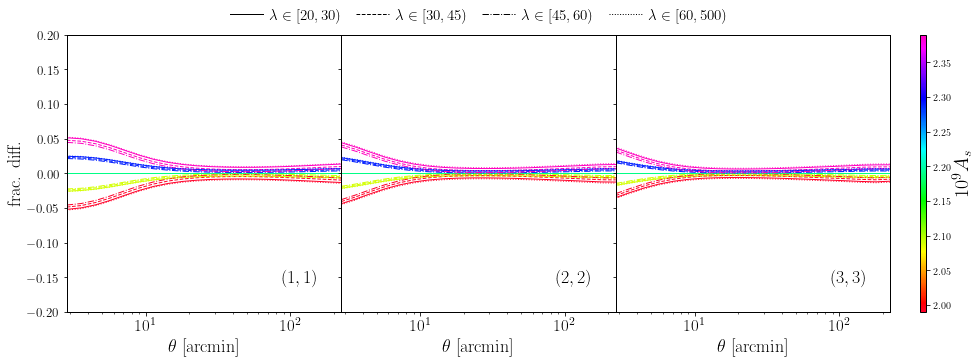

In [23]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$10^9 A_s$",
                  richnesslabel = richness_label,
                  ylim = [0.8, 1.2],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

## Sweep of the mass–richness relation

The mass–richness relation (eqs. 18–19 of the paper) enters through `MOR = [ln lambda_0, A_lambda, sigma_int, B_lambda]`. It changes no cosmology, so these sweeps reuse the CAMB run of the fiducial point, and the 3x2pt blocks do not depend on it. The first sweep varies the amplitude $\ln\lambda_0$ within $\pm0.2$ of 4.26. A larger value gives every halo a larger richness, so each richness bin collects less massive and more abundant halos: the counts rise, while the lensing and clustering amplitudes, which follow the mean mass and bias of the bin, fall.

In [24]:
param = np.linspace(DES_CL_LNLAMBDA0 - 0.2, DES_CL_LNLAMBDA0 + 0.2, 5)
N_param, sigma_param, wcc_param, wcg_param = [], [], [], []
for x in param:
    MOR = [x, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]
    N_param.append(nw.N_cluster(MOR=MOR))
    sigma_param.append(nw.sigma_cluster(MOR=MOR))
    wcc_param.append(nw.w_cc(selection_bias=True, MOR=MOR))
    wcg_param.append(nw.w_cg(selection_bias=True, MOR=MOR))

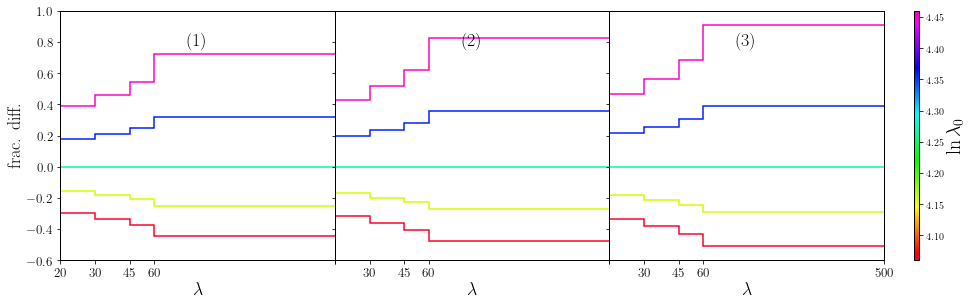

In [25]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$\ln\lambda_0$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 2.0],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

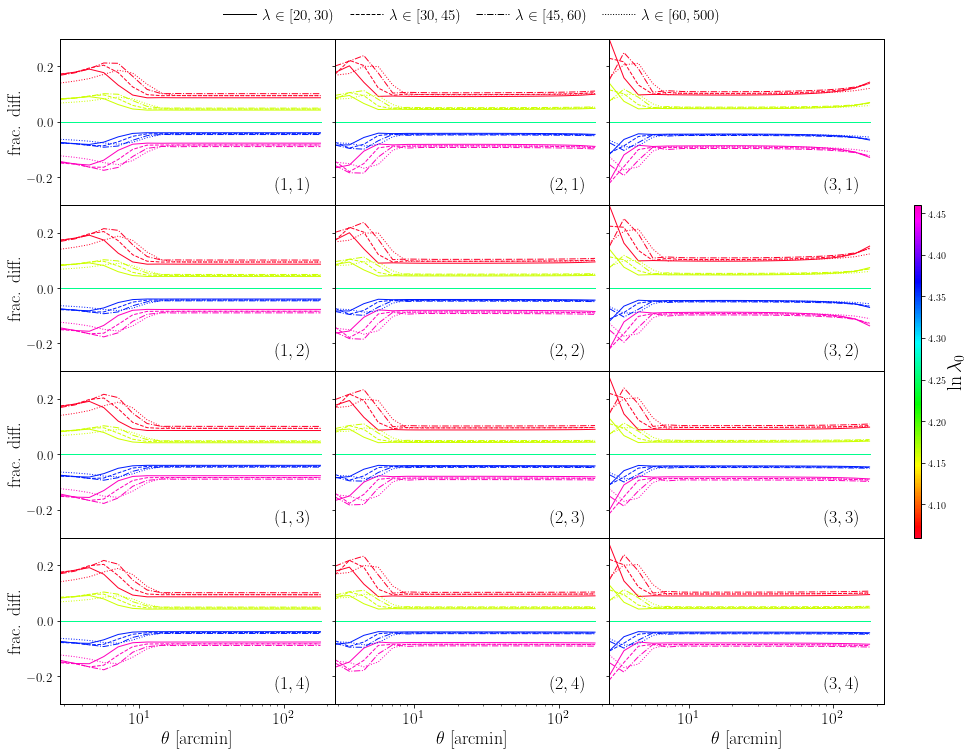

In [26]:
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$\ln\lambda_0$",
                            richnesslabel = richness_label,
                            ylim = [0.7, 1.3],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

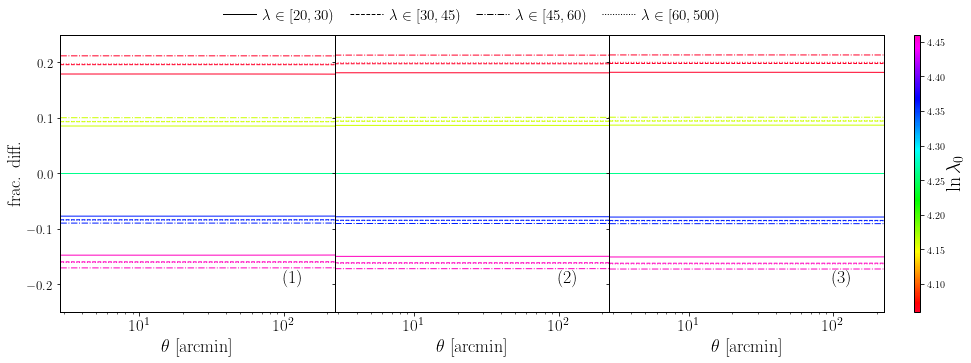

In [27]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$\ln\lambda_0$",
                  richnesslabel = richness_label,
                  ylim = [0.75, 1.25],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

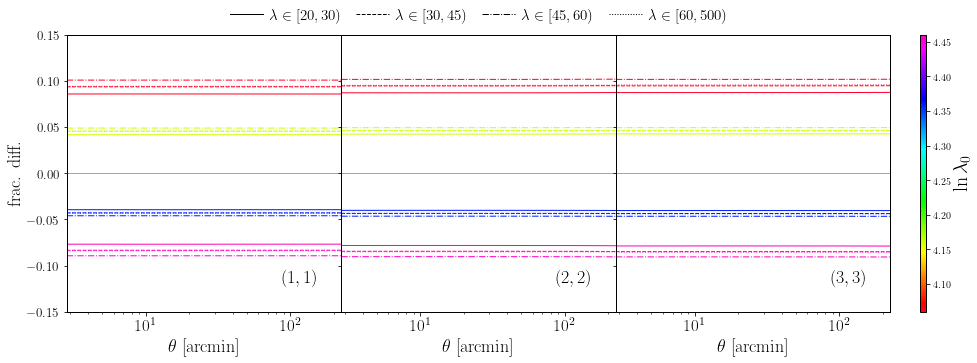

In [28]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$\ln\lambda_0$",
                  richnesslabel = richness_label,
                  ylim = [0.85, 1.15],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

### The intrinsic scatter $\sigma_{\rm int}$

The second sweep varies the intrinsic scatter of $\ln\lambda$ at fixed mass between 0.10 and 0.30. The mass function falls steeply with mass, so a broader scatter moves more low-mass halos up into a richness bin than high-mass halos down into it (Eddington bias): it tends to raise the counts and to lower the mean mass of each bin.

In [29]:
# the intrinsic scatter of the richness at fixed mass
param = np.linspace(0.10, 0.30, 5)
N_param, sigma_param, wcc_param = [], [], []
for x in param:
    MOR = [DES_CL_LNLAMBDA0, DES_CL_A_LAMBDA, x, DES_CL_B_LAMBDA]
    N_param.append(nw.N_cluster(MOR=MOR))
    sigma_param.append(nw.sigma_cluster(MOR=MOR))
    wcc_param.append(nw.w_cc(selection_bias=True, MOR=MOR))

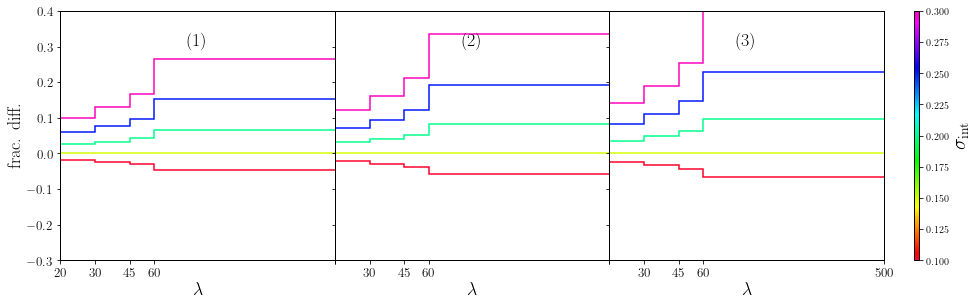

In [30]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"$\sigma_{\rm int}$",
                   richness_edges = richness_edges,
                   ylim = [0.7, 1.4],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

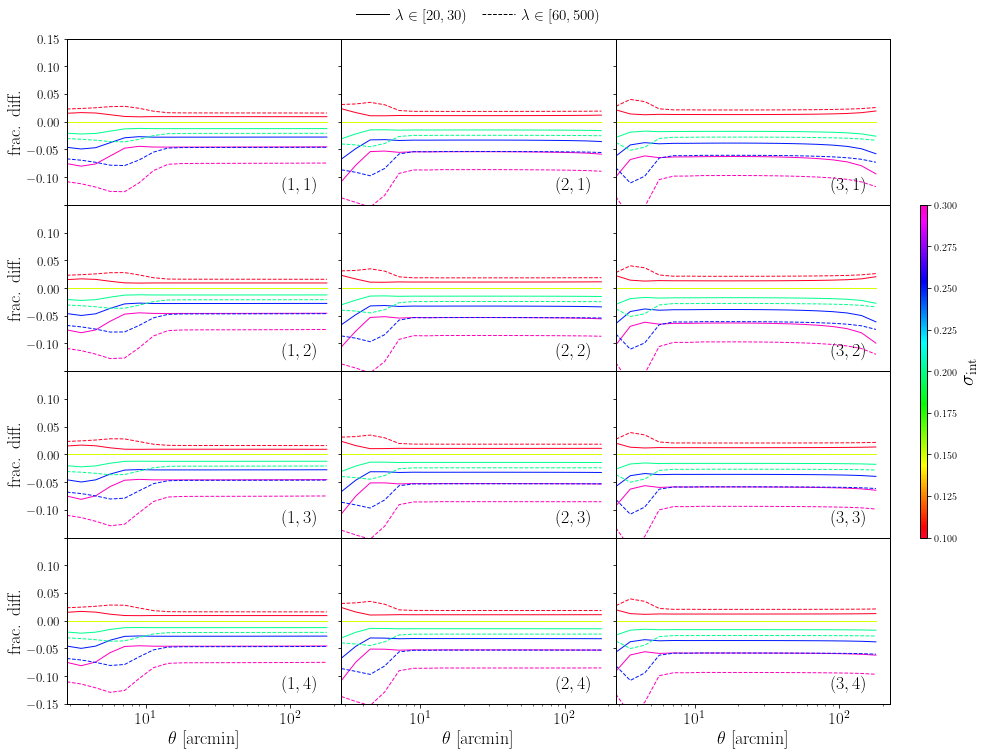

In [31]:
# the lowest and the highest richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$\sigma_{\rm int}$",
                            richnesslabel = richness_label,
                            ylim = [0.85, 1.15],
                            richness = [0, nrichness-1],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

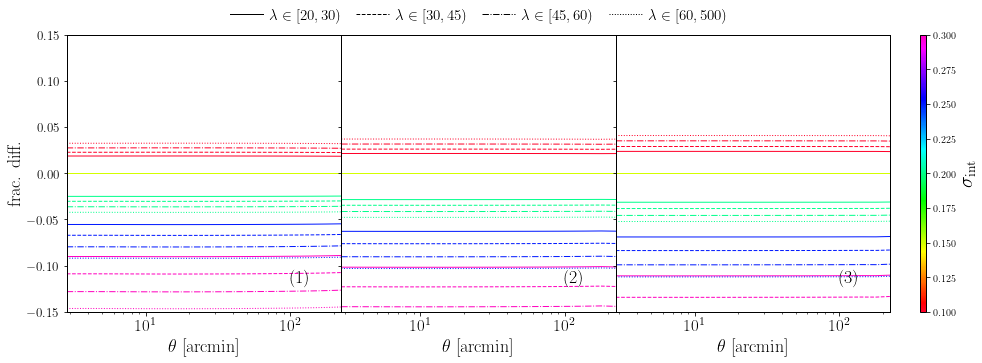

In [32]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$\sigma_{\rm int}$",
                  richnesslabel = richness_label,
                  ylim = [0.85, 1.15],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

## Sweep of the selection bias

Richness-selected clusters sit preferentially in filaments aligned with the line of sight, which boosts their lensing and clustering signals. Eq. 23 models this with the factor $B(\theta)=b_{s1}+b_{s2}\exp[-\theta\chi(\bar z)/r_0]$ on $\Sigma$ and $w_{cg}$, and $B(\theta)^2$ on $w_{cc}$, with `SEL = [b_s1, b_s2, r_0 [Mpc/h], s3]`. $B$ tends to $b_{s1}$ at comoving separations $\theta\chi(\bar z)\gg r_0$ and to $b_{s1}+b_{s2}$ at small separations. The counts do not depend on it. The first sweep varies the amplitude $b_{s2}$ of the scale-dependent part; because $B$ does not depend on the richness, one richness bin or pair is enough.

In [33]:
param = np.linspace(0.0, 0.4, 5)
sigma_param, wcc_param, wcg_param = [], [], []
for x in param:
    SEL = [DES_CL_BS1, x, DES_CL_R0, DES_CL_BSZ]
    sigma_param.append(nw.sigma_cluster(SEL=SEL))
    wcc_param.append(nw.w_cc(selection_bias=True, SEL=SEL))
    wcg_param.append(nw.w_cg(selection_bias=True, SEL=SEL))

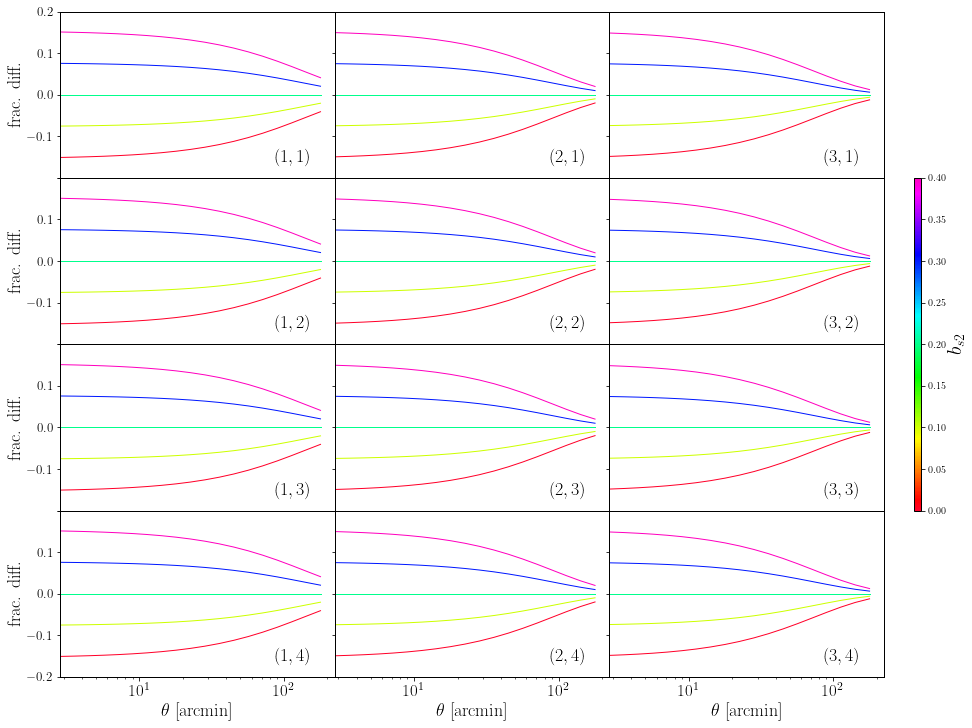

In [34]:
# the ratio is the same for every richness bin (B does not depend on
# the richness): one bin is enough
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$b_{s2}$",
                            richnesslabel = richness_label,
                            ylim = [0.8, 1.2],
                            richness = 0,
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

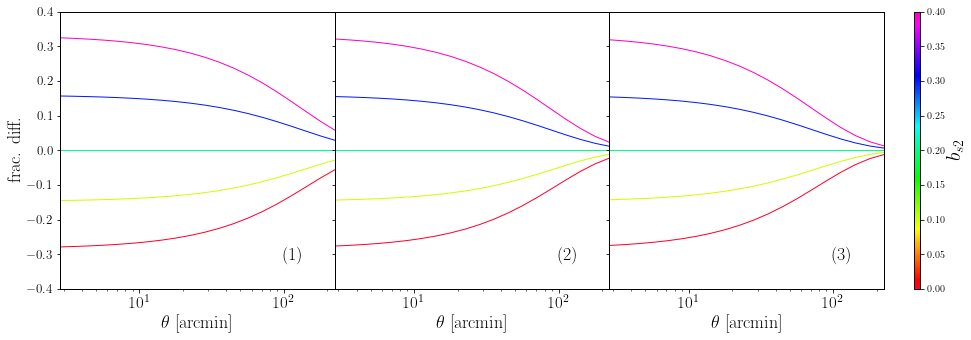

In [35]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$b_{s2}$",
                  ylim = [0.6, 1.4],
                  pairs = [(0, 0)],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

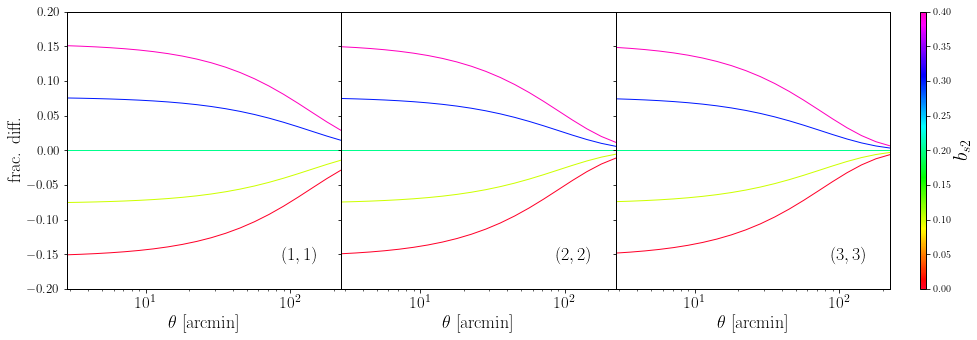

In [36]:
pdc.plot_wcg_tomo(theta_wcg = wcg_param,
                  theta_wcg_ref = wcg_ref,
                  param = param,
                  colorbarlabel = r"$b_{s2}$",
                  richnesslabel = richness_label,
                  ylim = [0.8, 1.2],
                  richness = 0,
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

### The transition scale $r_0$

The second sweep varies $r_0$ between 10 and 50 comoving Mpc/$h$: the separation over which the scale-dependent part $b_{s2}\exp[-\theta\chi(\bar z)/r_0]$ falls by a factor $e$.

In [37]:
# the scale r_0 of the selection bias
param = np.linspace(10.0, 50.0, 5)
sigma_param, wcc_param = [], []
for x in param:
    SEL = [DES_CL_BS1, DES_CL_BS2, x, DES_CL_BSZ]
    sigma_param.append(nw.sigma_cluster(SEL=SEL))
    wcc_param.append(nw.w_cc(selection_bias=True, SEL=SEL))

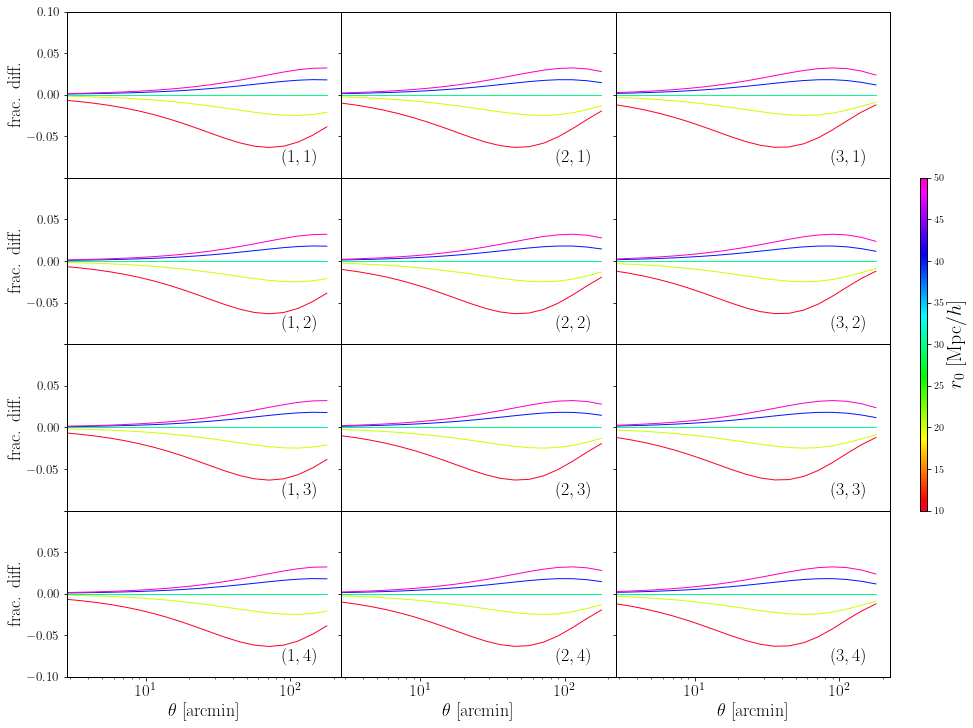

In [38]:
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"$r_0\ [{\rm Mpc}/h]$",
                            richnesslabel = richness_label,
                            ylim = [0.9, 1.1],
                            richness = 0,
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

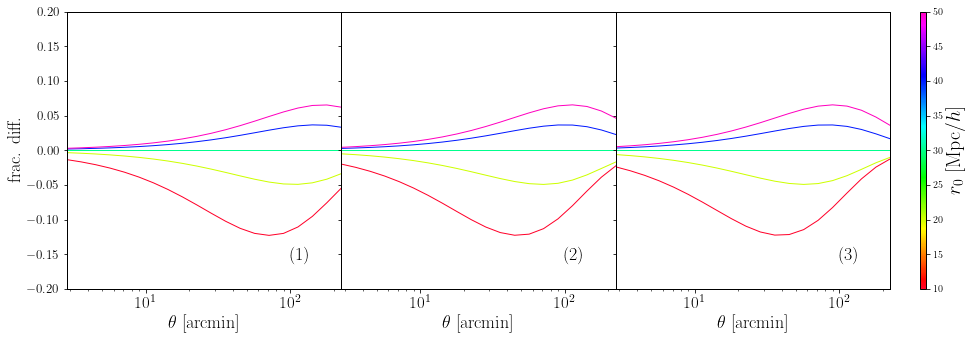

In [39]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"$r_0\ [{\rm Mpc}/h]$",
                  ylim = [0.8, 1.2],
                  pairs = [(0, 0)],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

## Changing the angular binning without restarting the kernel

The real-space statistics are sums over multipoles of $C_\ell$ times Legendre polynomials averaged over each angular bin. Cosmolike computes these bin-averaged kernels once and caches them in static C variables, keyed by the number of angular bins and by a table key. Each wrapper call re-initializes the binning and draws a new table key (through `init_accuracy_boost`), so the cache is rebuilt and a new binning takes effect within one kernel session. The cells compute $w_{cc}$ and the cluster $\gamma_t$ with 10, 15, 20 and 30 bins between 2.5 and 250 arcmin; the markers of all binnings should trace one curve, up to the averaging over bins of different widths.

In [40]:
nthetas = [10, 15, 20, 30]
wcc_ntheta = []
gammat_ntheta = []
for x in nthetas:
    wcc_ntheta.append(nw.w_cc(selection_bias=True, ntheta=x))
    gammat_ntheta.append(nw.gamma_t_cluster(ntheta=x))

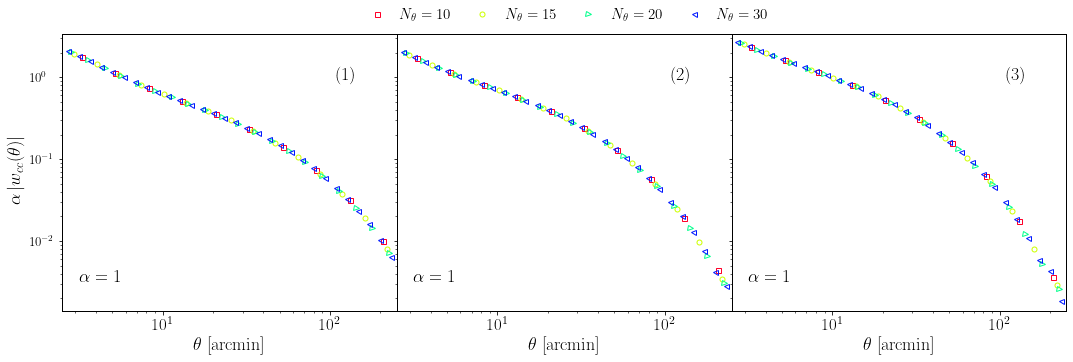

In [41]:
# one richness pair: the markers and the colors then follow the list entries;
# the list comprehension in legend writes one label per number of bins
pdc.plot_wcc_tomo(theta_wcc = wcc_ntheta,
                  marker = ['s', 'o', ">", "<"],
                  markersize = 5,
                  pairs = [(0, 0)],
                  legend = [r"$N_\theta = %d$"%x for x in nthetas],
                  thetashow = [2.5, 250],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17,
                  rescale = 1,
                  ydecades = 4)

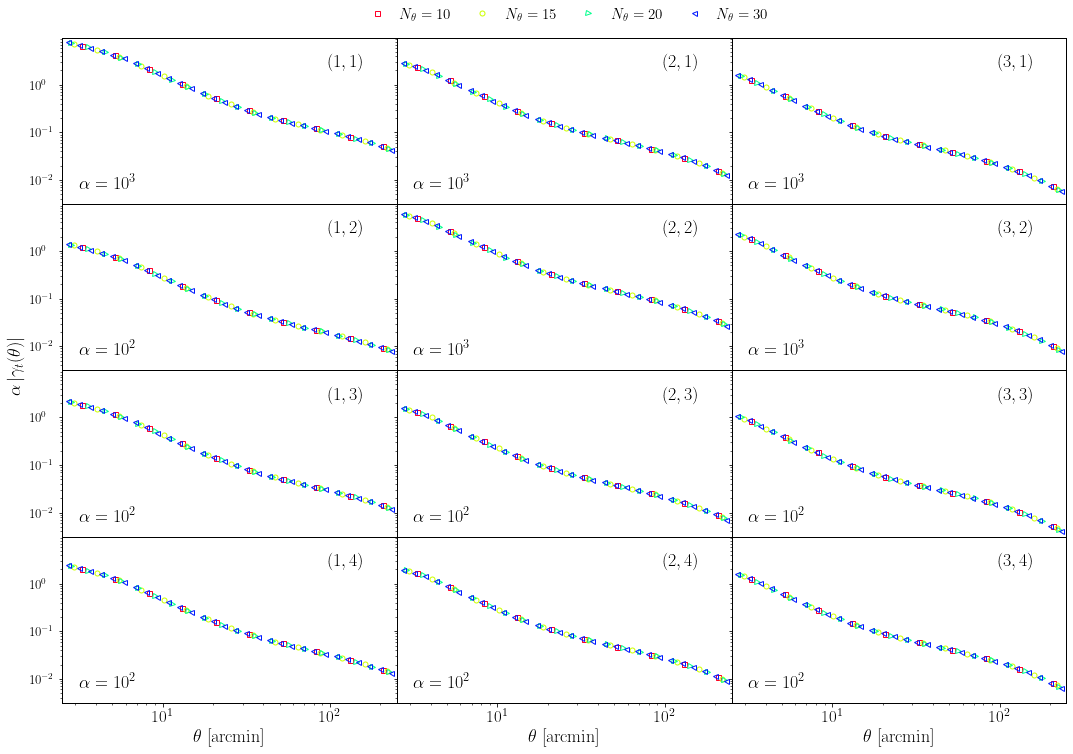

In [42]:
pdc.plot_gammat_cluster_tomo(theta_gammat = gammat_ntheta,
                             marker = ['s', 'o', ">", "<"],
                             markersize = 5,
                             richness = 0,
                             legend = [r"$N_\theta = %d$"%x for x in nthetas],
                             thetashow = [2.5, 250],
                             figsize = (18, 12),
                             bintextsize = 18,
                             yaxislabelsize = 18,
                             xaxislabelsize = 18,
                             yaxisticklabelsize = 13,
                             xaxisticklabelsize = 17,
                             rescale = 1,
                             ydecades = 4)

## Cosmolike's accuracy setting

`CLAccuracyBoost` refines Cosmolike's numerical sampling while CAMB's own accuracy stays fixed. The wrappers apply the likelihood's rules: the boost multiplies the density of Cosmolike's interpolation tables and of the redshift and wavenumber grids handed to `set_cosmology`, the integration level rises by about $3\,(\text{boost}-1)$, and the internal $C_\ell$ table extends to `lmax` $+\,20000\,(\text{boost}-1)$. Each value still runs CAMB once, because the grids it fills change. The sweep covers boosts from 1 to 3 (the project README advises keeping the boost at 3 or below). The ratios to the boost-1 reference measure the numerical error of the default settings; read them against the narrow `ylim` bands, $\pm0.02\%$ for the counts, $\pm3\%$ for $\Sigma$ and $\pm0.2\%$ for $w_{cc}$.

In [43]:
param = np.linspace(1.0, 3.0, 5)
N_param, sigma_param, wcc_param = [], [], []
for x in param:
    # CLAccuracyBoost refines only Cosmolike's sampling; CAMB's accuracy stays fixed
    N_param.append(nw.N_cluster(CLAccuracyBoost=x))
    sigma_param.append(nw.sigma_cluster(CLAccuracyBoost=x))
    wcc_param.append(nw.w_cc(selection_bias=True, CLAccuracyBoost=x))

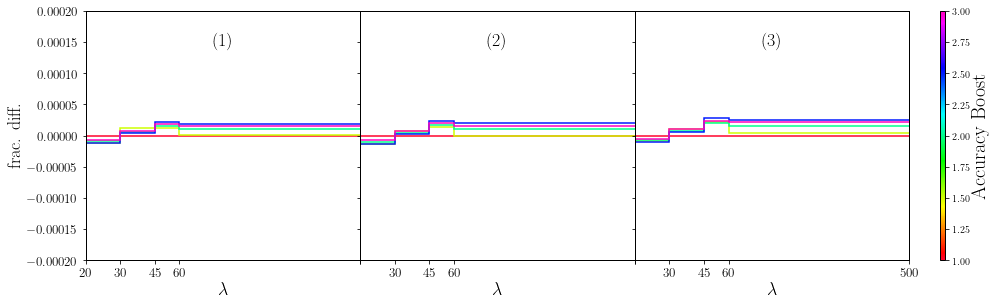

In [44]:
pdc.plot_N_cluster(N = N_param,
                   N_ref = N_ref,
                   param = param,
                   colorbarlabel = r"Accuracy Boost",
                   richness_edges = richness_edges,
                   ylim = [0.9998, 1.0002],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

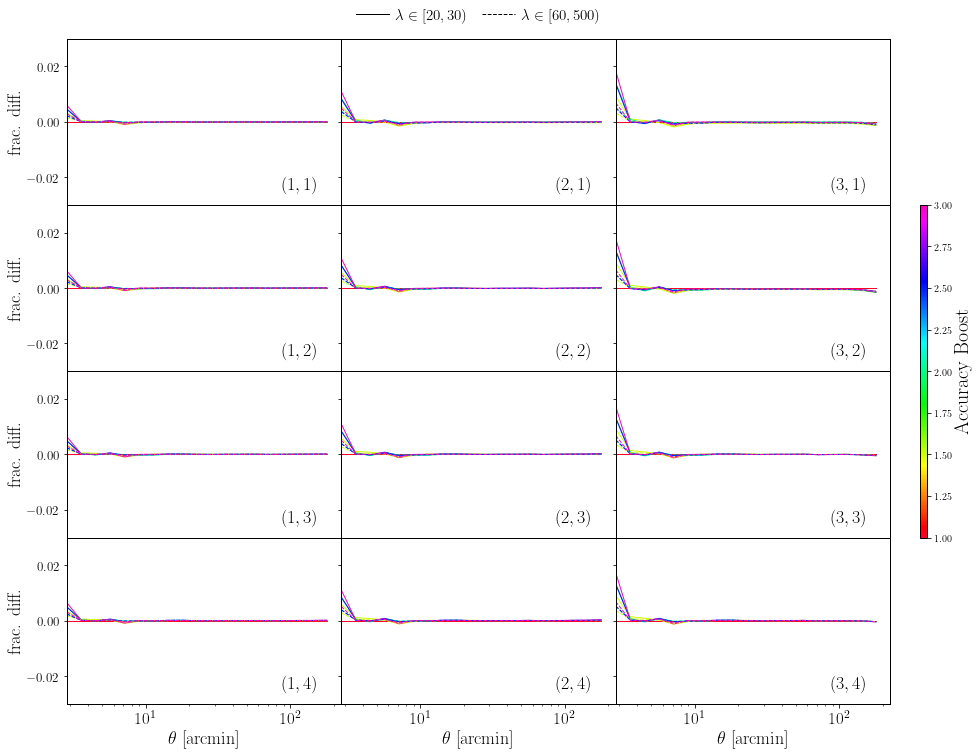

In [45]:
# the lowest and the highest richness bin
pdc.plot_sigma_cluster_tomo(theta_sigma = sigma_param,
                            sigma_ref = sigma_ref,
                            param = param,
                            colorbarlabel = r"Accuracy Boost",
                            richnesslabel = richness_label,
                            ylim = [0.97, 1.03],
                            richness = [0, nrichness-1],
                            bintextpos = [0.85, 0.12],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17)

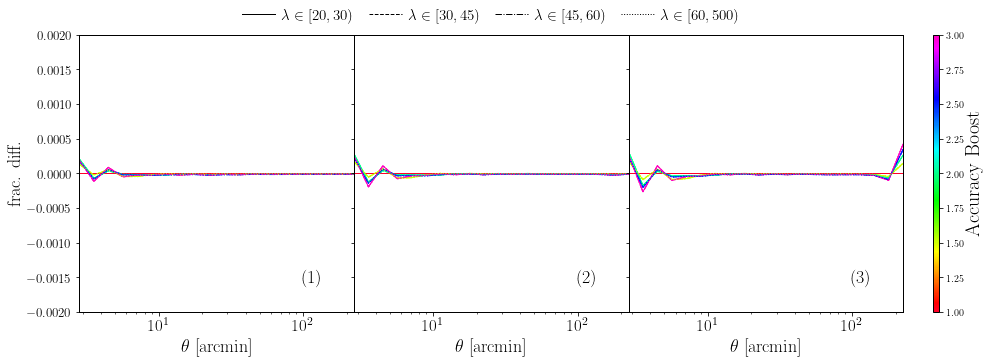

In [46]:
pdc.plot_wcc_tomo(theta_wcc = wcc_param,
                  theta_wcc_ref = wcc_ref,
                  param = param,
                  colorbarlabel = r"Accuracy Boost",
                  richnesslabel = richness_label,
                  ylim = [0.998, 1.002],
                  bintextpos = [0.85, 0.12],
                  figsize = (18, 5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

## $\chi^2$ against the synthetic 6x2pt + N data vector

`nw.get_chi2` runs the likelihood's data-vector call. `nw.get_datavector` sets the complete interface state at the requested point; `ci.compute_data_vector_cluster_masked` assembles the 2812-entry theory vector $m$ in the block order `ss`, `gs`, `gg`, `cg`, `N`, `cc`, `cs`, with zeros at masked entries; and `ci.compute_chi2_cluster` returns
$$\chi^2=\sum_{i,j}(d_i-m_i)\,(C^{-1})_{ij}\,(d_j-m_j),$$
where $d$ is the synthetic data, $C$ the loaded covariance of the entries that the mask keeps, and the sum runs over those entries. At the fiducial point $\chi^2$ is small but not zero: the data were generated through Cobaya's CAMB run, while this notebook runs CAMB through `cnu.get_camb_cosmology` with its own sampling.

The last two cells scan $\ln\lambda_0$ over $\pm0.03$ around the fiducial value with every other parameter fixed. For a Gaussian likelihood, $\chi^2$ near its minimum is close to a parabola, and the shift at which it rises by 1 above the minimum estimates the $1\sigma$ error of $\ln\lambda_0$ when all other parameters are held fixed.

In [47]:
# The synthetic data vector is the likelihood's model at the fiducial point
# (scripts/make_synthetic_data.py), so chi2 is small there; it is not
# exactly zero because this notebook's CAMB run is not the cobaya one.
print(r"$\chi^2$ (fiducial) = %.3e"%nw.get_chi2())
print(r"$\chi^2$ (omegam = 0.31) = %.3f"%nw.get_chi2(omegam=0.31))

$\chi^2$ (fiducial) = 1.615e-05


$\chi^2$ (omegam = 0.31) = 305.396


In [48]:
param = np.linspace(DES_CL_LNLAMBDA0 - 0.03, DES_CL_LNLAMBDA0 + 0.03, 7)
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(MOR=[x, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]))

Text(0, 0.5, '$\\chi^2$')

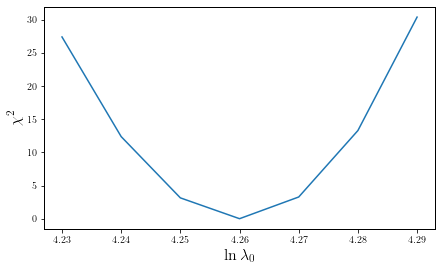

In [49]:
plt.figure(figsize=(7, 4))
plt.plot(param, chi2)
plt.xlabel(r"$\ln\lambda_0$", fontsize=16)
plt.ylabel(r"$\chi^2$", fontsize=16)